# Эксперименты

Режимы запуска:
- `auto` — сначала ищет уже готовые артефакты в папке `results`, и если их нет, запускает эксперимент.
- `reuse` — использует только уже сохранённые артефакты или уже обученную модель, ничего не пересчитывает.
- `rerun` — игнорирует старые результаты и запускает zero-shot/fine-tuning заново.


In [1]:
from pathlib import Path

from src import (
    DEFAULT_RUN_MODES,
    FINE_TUNED_EXPERIMENT_NAMES,
    ZERO_SHOT_EXPERIMENT_NAMES,
    analyze_results_behavior,
    build_comparative_analysis,
    collect_metric_comparison,
    create_data_limits,
    create_runtime_config,
    filter_results_by_kind,
    initialize_runtime,
    plot_behavior_comparison,
    plot_metric_comparison,
    plot_pathology_recall_comparison,
    print_metrics,
    print_platform_summary,
    print_result_sources,
    run_experiments,
)
from src.evaluation import load_model_and_processor
from src.utils import clear_memory


## Конфигурация


In [2]:
RUN_MODES = dict(DEFAULT_RUN_MODES)

# RUN_MODES["iu_xray_zero_shot"] = "reuse"
# RUN_MODES["mimic_cxr_zero_shot"] = "rerun"
# RUN_MODES["iu_xray_fine_tuned"] = "auto"
# RUN_MODES["mimic_cxr_fine_tuned"] = "rerun"

SELECTED_EXPERIMENTS = ZERO_SHOT_EXPERIMENT_NAMES + FINE_TUNED_EXPERIMENT_NAMES

config = create_runtime_config(
    results_root_dir=Path("results"),
    data_limits=create_data_limits(
        zero_shot=None,
        train=None,
        validation=None,
        test=None,
    ),
)

state = initialize_runtime(config)
print_platform_summary(state["platform"])


Конфигурация запуска
------------------------------
device               mps
dtype                torch.float16
train_batch_size     1
eval_batch_size      1
grad_accum_steps     8
max_new_tokens       80
num_beams            2


## Сводка модели

Выведем с помощью `torchinfo` информацию о модели.

In [3]:
processor, model = load_model_and_processor(
    state["config"]["model_name"],
    state["platform"],
)

del processor
del model
clear_memory(state["platform"]["device"])


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1289 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie language_model.shared.weight to language_model.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Сводка модели через torchinfo: Salesforce/blip2-flan-t5-xl
------------------------------
Layer (type (var_name))                                                          Param #                   Trainable
Blip2ForConditionalGeneration (Blip2ForConditionalGeneration)                    24,576                    True
├─Blip2VisionModel (vision_model)                                                --                        True
│    └─Blip2VisionEmbeddings (embeddings)                                        1,192,576                 True
│    └─Blip2Encoder (encoder)                                                    984,756,864               True
│    └─LayerNorm (post_layernorm)                                                2,816                     True
├─Blip2QFormerModel (qformer)                                                    --                        True
│    └─LayerNorm (layernorm)                                                     1,536                     True
│    └─Dr

## Запуск экспериментов


Запустим zero-shot и fine-tuning эксперименты для датасетов `iu-xray` и `mimic-cxr`. 

In [4]:
results = run_experiments(
    state,
    experiment_names=SELECTED_EXPERIMENTS,
    run_modes=RUN_MODES,
)

print_result_sources(results)



Running iu_xray_zero_shot [auto]

Running mimic_cxr_zero_shot [auto]

Running iu_xray_fine_tuned [auto]

Running mimic_cxr_fine_tuned [auto]
Experiment sources
------------------------------
iu_xray_zero_shot        saved_artifacts
mimic_cxr_zero_shot      saved_artifacts
iu_xray_fine_tuned       saved_artifacts
mimic_cxr_fine_tuned     saved_artifacts


## Лексические метрики качества

Рассмотрим сначала стандартные лексические метрики `BLEU-4`, `ROUGE-L` и `METEOR`. 

Они показывают, насколько предсказанный текст совпадает с референсным заключением на уровне слов и фраз. Эти метрики подходят для первичного сравнения `zero-shot` и `fine-tuning`, однако сами по себе они не позволяют отличить содержательное улучшение модели от повторения частотных шаблонов.


iu_xray_zero_shot
------------------------------
BLEU-4                   0.0000
ROUGE-1                  0.0393
ROUGE-L                  0.0213
METEOR                   0.0224
avg_prediction_length    7.9104
avg_reference_length     11.0598

mimic_cxr_zero_shot
------------------------------
BLEU-4                   0.0010
ROUGE-1                  0.0603
ROUGE-L                  0.0431
METEOR                   0.0292
avg_prediction_length    8.4664
avg_reference_length     16.3806

iu_xray_fine_tuned
------------------------------
BLEU-4                   0.0381
ROUGE-1                  0.3871
ROUGE-L                  0.3872
METEOR                   0.3662
avg_prediction_length    3.9227
avg_reference_length     11.0598

mimic_cxr_fine_tuned
------------------------------
BLEU-4                   0.0084
ROUGE-1                  0.1684
ROUGE-L                  0.1655
METEOR                   0.1653
avg_prediction_length    3.9787
avg_reference_length     16.3806



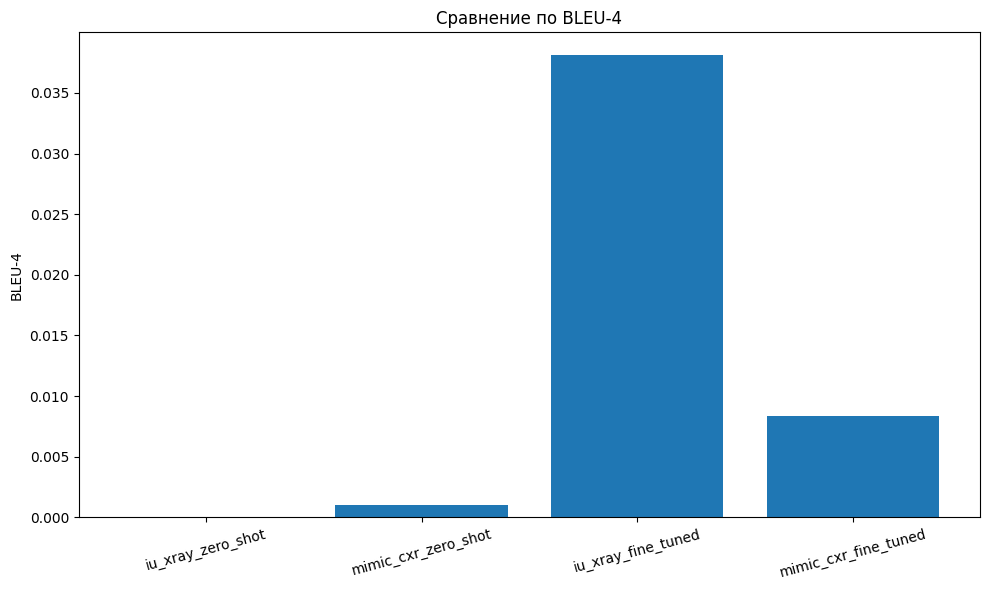

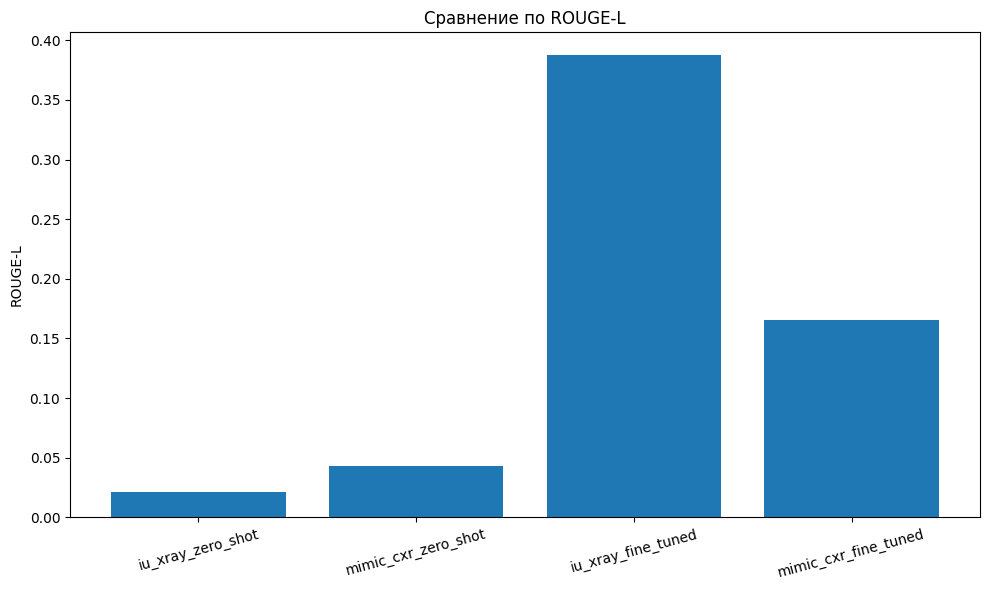

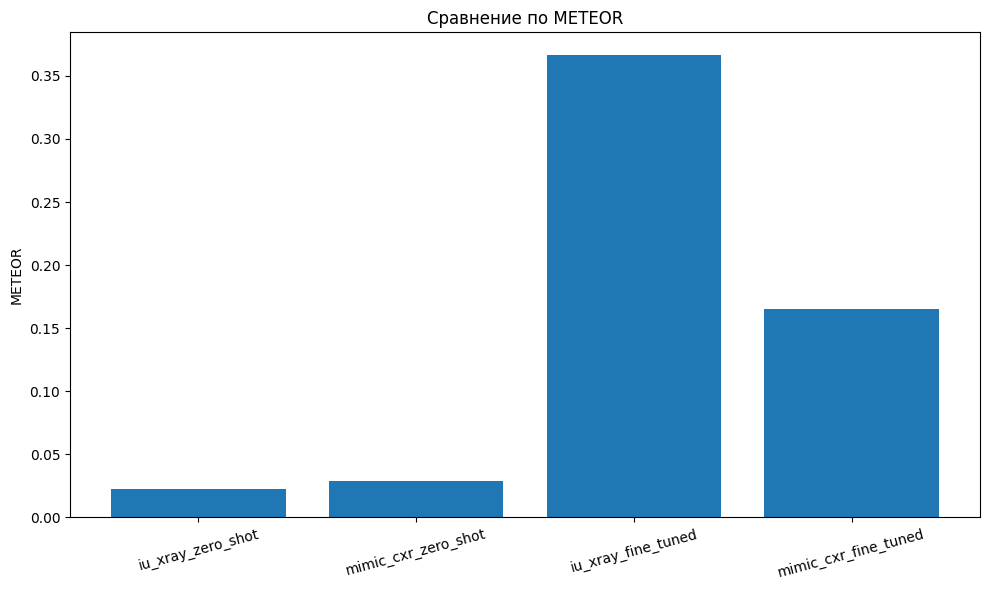

In [5]:
for experiment_name, result in results.items():
    print_metrics(experiment_name, result["metrics"])
    print()

all_metric_comparison = collect_metric_comparison(results)
for metric_name in ["BLEU-4", "ROUGE-L", "METEOR"]:
    plot_metric_comparison(
        all_metric_comparison,
        metric_name=metric_name,
        title=f"Сравнение по {metric_name}",
        output_path=state["plots_root_dir"] / f"lexical_{metric_name.lower().replace('-', '_')}.png",
    )


Обучение выглядит особенно успешным на датасете `IU X-Ray`: после `fine-tuning` значения BLEU-4, ROUGE-L и METEOR здесь заметно выше, чем на `MIMIC-CXR`. На этом этапе можно количественно сравнить, насколько сильно `fine-tuning` улучшает лексическое совпадение относительно `zero-shot`.

Чтобы сделать это сравнение явным, ниже приведём краткий сравнительный анализ именно по метрикам. После этого перейдём к вопросу, отражают ли эти метрики реальное качество медицинского содержания или частично маскируют переход модели к повторяющимся шаблонным заключениям.


## Сравнительный анализ по метрикам

Рассмотрим отдельно, как меняются BLEU-4, ROUGE-L и METEOR при переходе от `zero-shot` к `fine-tuning` на каждом датасете. Этот шаг фиксирует количественный выигрыш по лексическим метрикам, но ещё не отвечает на вопрос о содержательной корректности предсказаний.


In [6]:
analysis_text = build_comparative_analysis(results)
print(analysis_text)

Сравнительный анализ

Датасет: iu_xray
BLEU-4: 0.0000 -> 0.0381 (+0.0381)
ROUGE-L: 0.0213 -> 0.3872 (+0.3659)
METEOR: 0.0224 -> 0.3662 (+0.3438)

Датасет: mimic_cxr
BLEU-4: 0.0010 -> 0.0084 (+0.0074)
ROUGE-L: 0.0431 -> 0.1655 (+0.1224)
METEOR: 0.0292 -> 0.1653 (+0.1361)



Полученный сравнительный анализ показывает, что по BLEU-4, ROUGE-L и METEOR `IU X-Ray` действительно выглядит сильнее. Однако теперь необходимо проверить, не достигается ли этот выигрыш за счёт упрощённой стратегии генерации, при которой модель часто выбирает безопасные отрицательные формулировки вместо содержательного описания патологии.


## Анализ поведения модели

Рассмотрим поведение модели после `fine-tuning` более подробно. Ниже последовательно проанализируем склонность к отрицательным заключениям, степень разнообразия формулировок и способность упоминать патологию в тех случаях, когда она действительно присутствует в референсе. Такая последовательность позволяет отделить рост лексических метрик от содержательного качества генерации.


In [7]:
fine_tuned_results = filter_results_by_kind(results, "fine_tuned")
behavior_summary = analyze_results_behavior(fine_tuned_results)

for experiment_name, summary in behavior_summary.items():
    print(experiment_name)
    print("-" * 40)
    print(f"Всего данных: {summary['samples']}")
    print(f"Уникальных предсказаний: {summary['unique_predictions']}")
    print(f"Доля уникальных предсказаний: {summary['unique_prediction_ratio']:.4f}")
    print(f"Доля пяти самых частых формулировок: {summary['top5_share']:.4f}")
    print(f"Доля ответов об отсутствии острых изменений: {summary['no_acute_rate']:.4f}")
    print(f"Доля ответов об отсутствии острых изменений в случаях с патологией: {summary['no_acute_on_abnormal_rate']:.4f}")
    print(f"Полнота упоминания патологии: {summary['any_pathology_recall']:.4f}")
    print()
    print("Наиболее частые формулировки:")
    for index, (prediction, count) in enumerate(summary['top_predictions'][:5], start=1):
        share = count / max(summary['samples'], 1)
        print(f"  {index}. {prediction} | count={count}, share={share:.4f}")
    print("-" * 40)


iu_xray_fine_tuned
----------------------------------------
Всего данных: 569
Уникальных предсказаний: 11
Доля уникальных предсказаний: 0.0193
Доля пяти самых частых формулировок: 0.9244
Доля ответов об отсутствии острых изменений: 0.9016
Доля ответов об отсутствии острых изменений в случаях с патологией: 0.8860
Полнота упоминания патологии: 0.0000

Наиболее частые формулировки:
  1. No acute cardiopulmonary abnormality. | count=261, share=0.4587
  2. No acute cardiopulmonary disease. | count=150, share=0.2636
  3. No acute cardiopulmonary abnormalities. | count=50, share=0.0879
  4. No active cardiopulmonary disease. | count=41, share=0.0721
  5. No active disease. | count=24, share=0.0422
----------------------------------------
mimic_cxr_fine_tuned
----------------------------------------
Всего данных: 4595
Уникальных предсказаний: 891
Доля уникальных предсказаний: 0.1939
Доля пяти самых частых формулировок: 0.7153
Доля ответов об отсутствии острых изменений: 0.4540
Доля ответов об 

Сначала рассмотрим общую долю ответов с формулировками об отсутствии острых изменений. Если модель действительно научилась выделять патологию, такая доля не должна становиться доминирующей на всём тестовом наборе. Для `IU X-Ray` здесь ожидается особенно выраженное смещение в сторону отрицательных шаблонов.


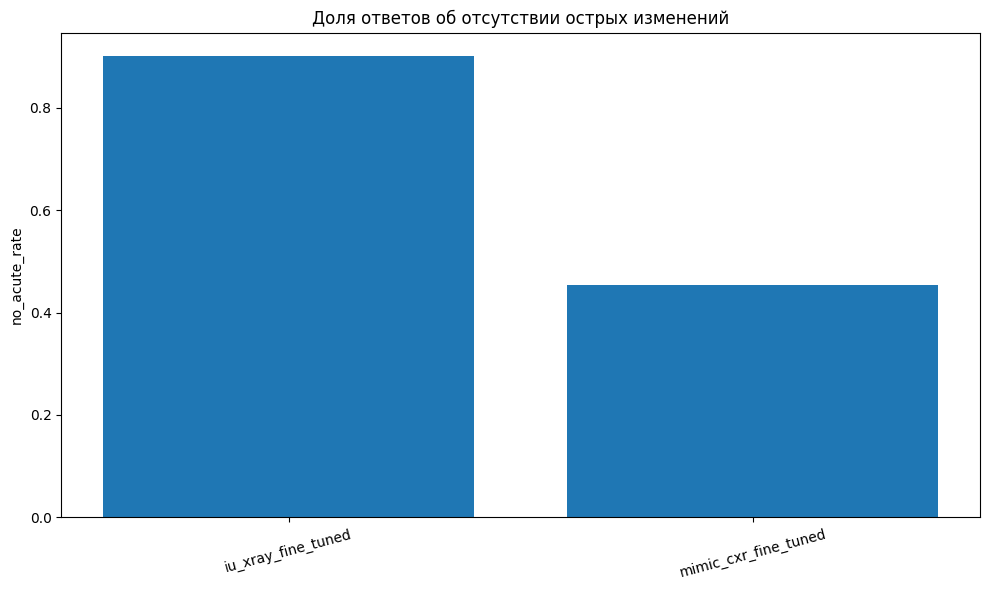

In [8]:
plot_behavior_comparison(
    behavior_summary,
    metric_name="no_acute_rate",
    title="Доля ответов об отсутствии острых изменений",
    output_path=state["plots_root_dir"] / "behavior_no_acute_rate.png",
)


Далее уточним, как ведёт себя модель именно на тех исследованиях, где в референсе присутствует патология. Если и в этих случаях модель продолжает часто выдавать заключение об отсутствии острых изменений, это уже указывает не просто на частотный шаблон, а на потерю содержательной чувствительности к патологическим находкам.


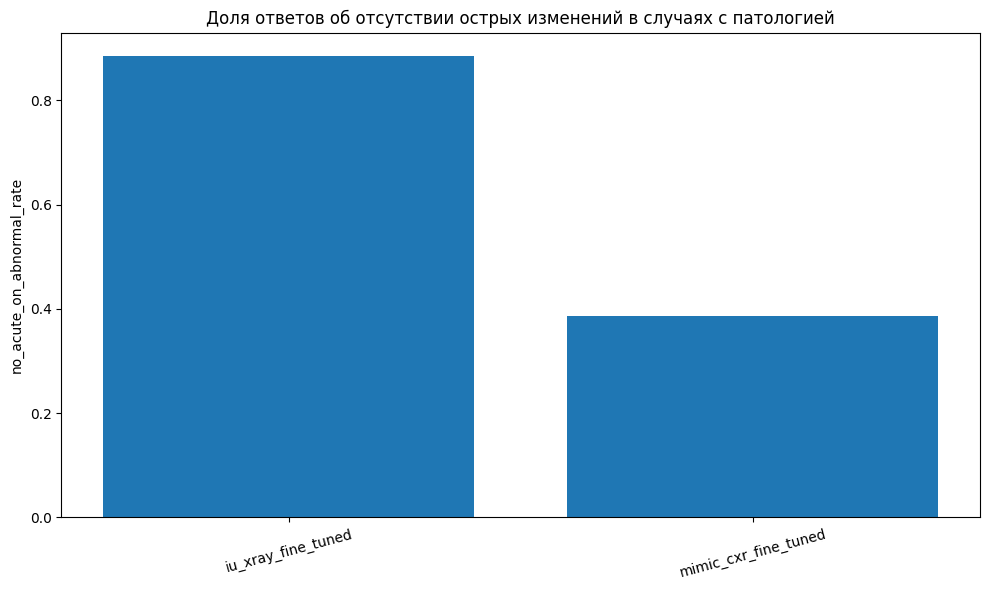

In [9]:
plot_behavior_comparison(
    behavior_summary,
    metric_name="no_acute_on_abnormal_rate",
    title="Доля ответов об отсутствии острых изменений в случаях с патологией",
    output_path=state["plots_root_dir"] / "behavior_no_acute_on_abnormal_rate.png",
)


После этого перейдём к разнообразию генерации. Доля уникальных предсказаний показывает, насколько широк набор формулировок, которыми пользуется модель. Низкое значение этой величины означает, что значительная часть выборки покрывается повторением небольшого числа однотипных ответов.


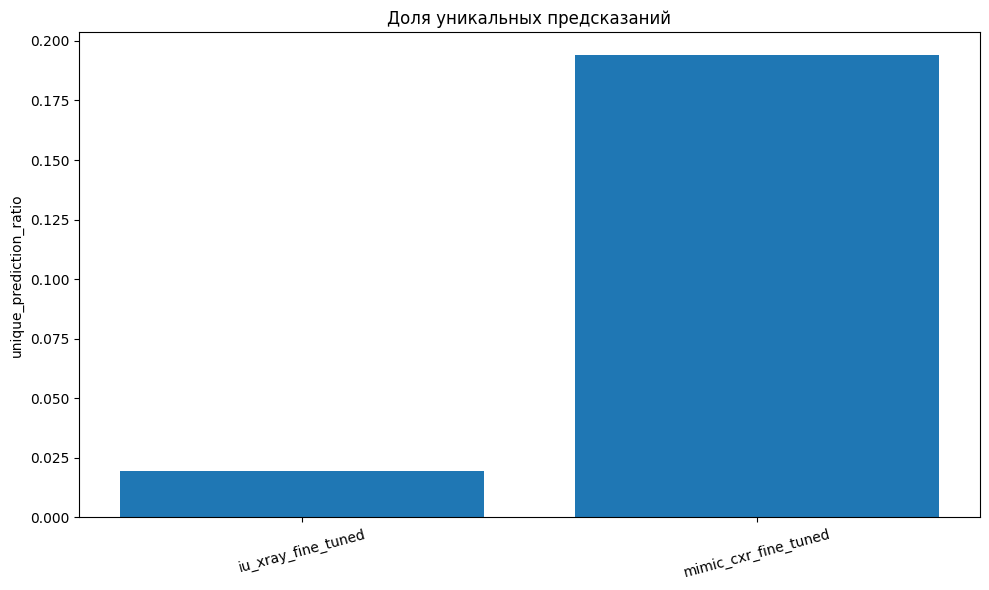

In [10]:
plot_behavior_comparison(
    behavior_summary,
    metric_name="unique_prediction_ratio",
    title="Доля уникальных предсказаний",
    output_path=state["plots_root_dir"] / "behavior_unique_prediction_ratio.png",
)


Следующий показатель измеряет, какая часть всей выборки покрывается пятью наиболее частыми формулировками. Чем выше эта доля, тем сильнее модель сосредоточена на небольшом наборе шаблонов. Для случая коллапса модели именно эта величина обычно быстро растёт.


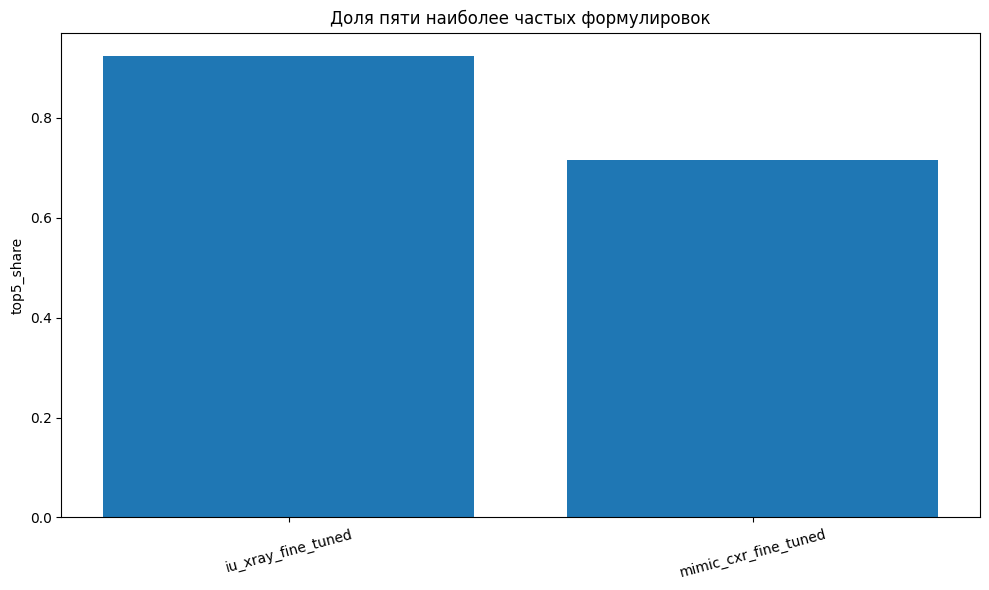

In [11]:
plot_behavior_comparison(
    behavior_summary,
    metric_name="top5_share",
    title="Доля пяти наиболее частых формулировок",
    output_path=state["plots_root_dir"] / "behavior_top5_share.png",
)


Теперь рассмотрим, насколько часто модель вообще упоминает патологию там, где она есть в референсе. Полнота упоминания патологии позволяет приблизиться к клинической интерпретации качества: высокая лексическая близость без упоминания патологических находок в таких случаях не может считаться полноценным улучшением модели.


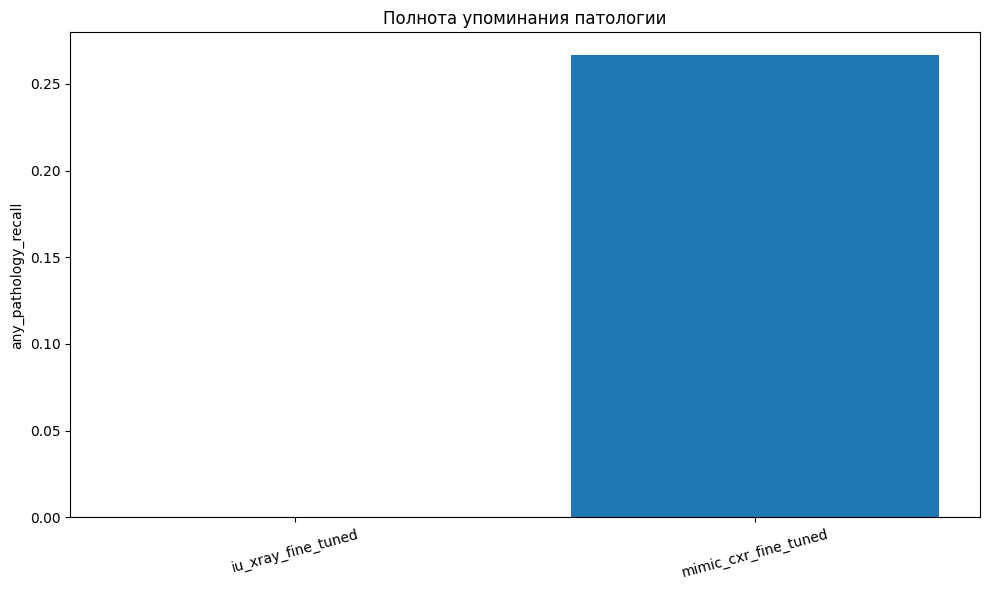

In [12]:
plot_behavior_comparison(
    behavior_summary,
    metric_name="any_pathology_recall",
    title="Полнота упоминания патологии",
    output_path=state["plots_root_dir"] / "behavior_any_pathology_recall.png",
)


Наконец, детализируем предыдущий результат по отдельным патологическим терминам. Такое сравнение показывает, является ли потеря полноты общим свойством модели или связана лишь с несколькими частными категориями находок. Именно на этом этапе удобно увидеть, насколько `MIMIC-CXR` сохраняет содержательное преимущество при более низких лексических метриках.


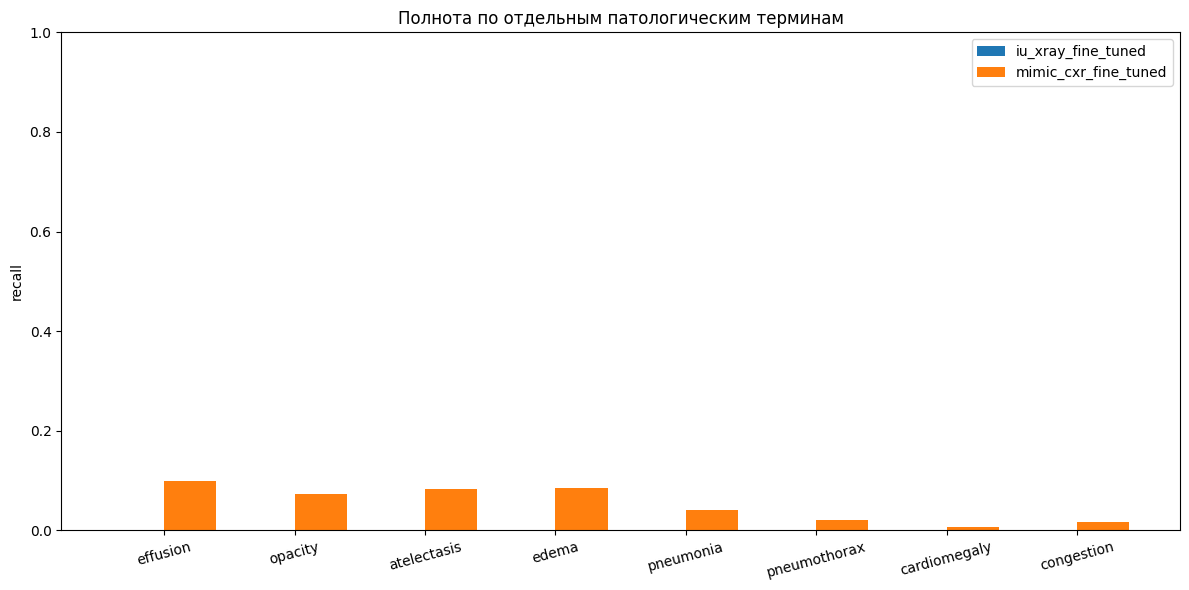

In [13]:
plot_pathology_recall_comparison(
    behavior_summary,
    title="Полнота по отдельным патологическим терминам",
    output_path=state["plots_root_dir"] / "behavior_pathology_term_recall.png",
)


Последовательный анализ этих показателей приводит к более точной интерпретации результата. На `IU X-Ray` обучение действительно повышает BLEU-4, ROUGE-L и METEOR, однако заметная часть выигрыша достигается за счёт перехода к повторяющимся отрицательным заключениям. На `MIMIC-CXR` лексические метрики ниже, но модель реже сваливается в шаблон об отсутствии острых изменений, сохраняет большее разнообразие ответов и чаще называет патологию в клинически значимых случаях.


## Вывод

Результаты обучения показывают, что `fine-tuning` улучшает BLEU-4, ROUGE-L и METEOR на обоих датасетах, однако интерпретация этого улучшения различается. Для `IU X-Ray` рост метрик сопровождается выраженным смещением к повторяющимся отрицательным заключениям, поэтому одна только лексическая близость здесь переоценивает качество модели. Для `MIMIC-CXR` абсолютные значения метрик ниже, но модель сохраняет более разнообразный набор формулировок и чаще упоминает патологию там, где она действительно присутствует в референсе. Следовательно, при оценке качества генерации радиологических заключений лексические метрики необходимо рассматривать совместно с поведенческими показателями, отражающими устойчивость модели к коллапсу и её способность воспроизводить клинически значимую информацию.
